In [ ]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

stocks = [
    "HDFCBANK.NS", "ICICIBANK.NS", "TCS.NS", "INFY.NS",
    "RELIANCE.NS", "MARUTI.NS", "LT.NS", "HINDUNILVR.NS"
]

benchmark = "^NSEI"

# Download data
raw_data = yf.download(stocks + [benchmark],
                       start="2020-01-01",
                       end="2025-12-31",
                       auto_adjust=True)

# Extract Close prices
data = raw_data["Close"]

# Rename columns (clean names for analysis)
data = raw_data["Close"].copy()

data = data.rename(columns={
    "HDFCBANK.NS": "HDFC",
    "ICICIBANK.NS": "ICICI",
    "TCS.NS": "TCS",
    "INFY.NS": "INFY",
    "RELIANCE.NS": "RELIANCE",
    "MARUTI.NS": "MARUTI",
    "LT.NS": "LT",
    "HINDUNILVR.NS": "HUL",
    "^NSEI": "NIFTY50"
})

# Handle missing values
data = data.ffill().dropna()

# Save cleaned data
data.to_csv("cleaned_stock_data.csv")

# Info
print(data.info())
print(data.head())

[*********************100%***********************]  9 of 9 completed


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1486 entries, 2020-01-01 to 2025-12-30
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   HDFC      1486 non-null   float64
 1   HUL       1486 non-null   float64
 2   ICICI     1486 non-null   float64
 3   INFY      1486 non-null   float64
 4   LT        1486 non-null   float64
 5   MARUTI    1486 non-null   float64
 6   RELIANCE  1486 non-null   float64
 7   TCS       1486 non-null   float64
 8   NIFTY50   1486 non-null   float64
dtypes: float64(9)
memory usage: 116.1 KB
None
Ticker            HDFC          HUL       ICICI        INFY           LT  \
Date                                                                       
2020-01-01  605.529358  1749.931396  519.137939  633.151062  1192.206787   
2020-01-02  609.389160  1751.286987  522.861572  631.303650  1224.379395   
2020-01-03  600.698792  1741.708374  521.169006  641.013489  1215.050659   
2020-01-06  587.6987

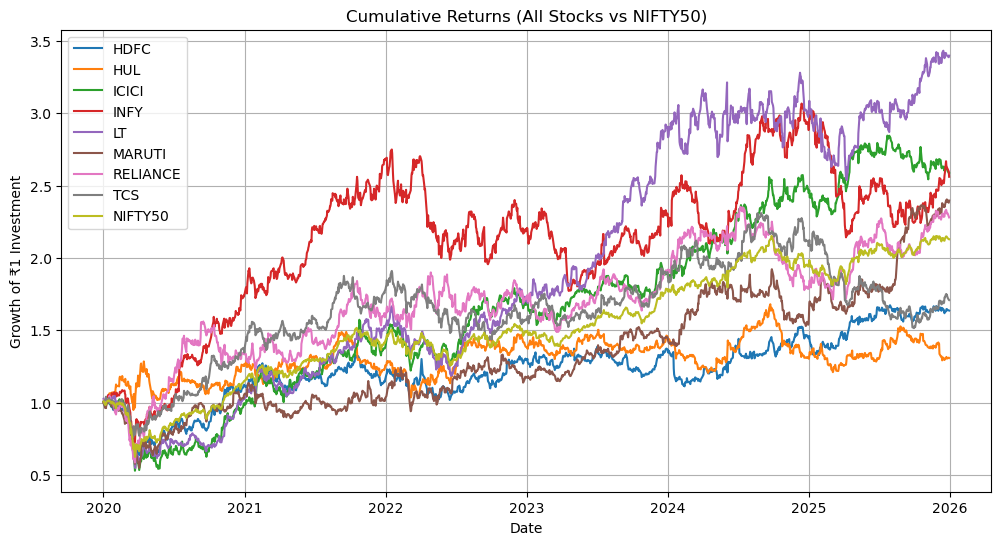

In [3]:
import matplotlib.pyplot as plt

# Daily returns
returns = data.pct_change().dropna()

# Cumulative returns
cumulative_returns = (1 + returns).cumprod()


plt.figure(figsize=(12,6))

for col in cumulative_returns.columns:
    plt.plot(cumulative_returns[col], label=col)

plt.title("Cumulative Returns (All Stocks vs NIFTY50)")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1 Investment")
plt.legend()
plt.grid()
plt.show()



 

In [4]:


trading_days = 252

# Calculate daily returns
returns = data.pct_change().dropna()

# Separate benchmark returns
benchmark_returns = returns["NIFTY50"]

# Annualized Volatility
volatility = returns.std() * np.sqrt(trading_days)

# Annualized Variance
variance = returns.var() * trading_days

# Beta calculation (vs NIFTY50)
beta = {}

for col in returns.columns:
    if col != "NIFTY50":
        cov = np.cov(returns[col], benchmark_returns)[0][1]
        var_benchmark = np.var(benchmark_returns)
        beta[col] = cov / var_benchmark

beta = pd.Series(beta)

# Add benchmark beta = 1 manually
beta["NIFTY50"] = 1.0

# Value at Risk (95%)
VaR_95 = returns.quantile(0.05)

# Risk Summary Table
risk_summary = pd.DataFrame({
    "Volatility (Annualized)": volatility,
    "Variance (Annualized)": variance,
    "Beta": beta,
    "VaR (95%)": VaR_95
})

print(risk_summary.sort_values(by="Volatility (Annualized)", ascending=False))

          Volatility (Annualized)  Variance (Annualized)      Beta  VaR (95%)
ICICI                    0.297220               0.088340  1.261953  -0.023552
MARUTI                   0.286763               0.082233  0.964881  -0.022981
RELIANCE                 0.282715               0.079928  1.114880  -0.023179
LT                       0.276407               0.076401  1.048708  -0.022735
INFY                     0.274133               0.075149  0.917750  -0.024742
HDFC                     0.256830               0.065962  1.072470  -0.023226
TCS                      0.237664               0.056484  0.760529  -0.020971
HUL                      0.231826               0.053744  0.553377  -0.019856
NIFTY50                  0.180922               0.032733  1.000000  -0.015249


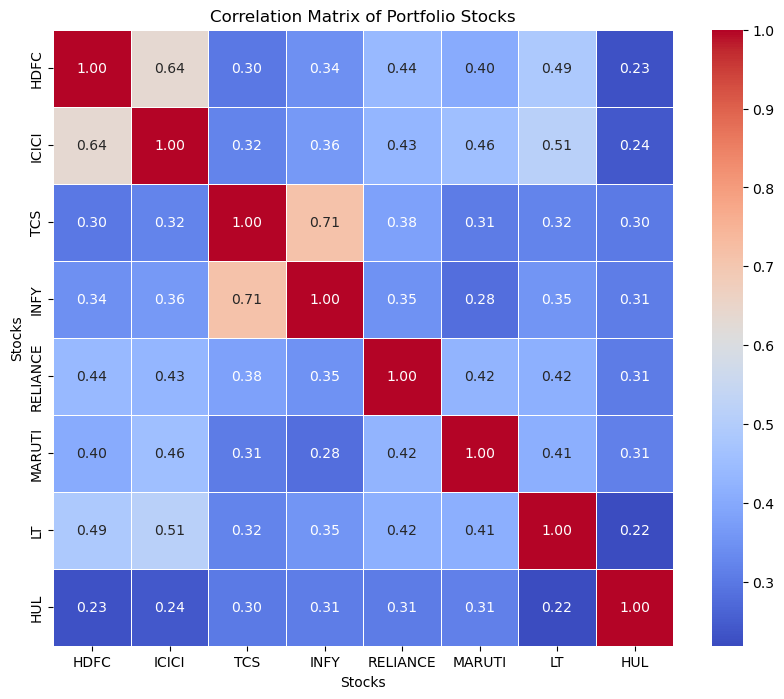


Correlation with NIFTY50:
Ticker
ICICI       0.767651
HDFC        0.754982
RELIANCE    0.712981
LT          0.685968
MARUTI      0.608343
INFY        0.605287
TCS         0.578563
HUL         0.431575
Name: NIFTY50, dtype: float64


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate daily returns from cleaned data
returns = data.pct_change().dropna()

# Correlation matrix (only stocks, exclude benchmark if needed)
stock_cols = ["HDFC", "ICICI", "TCS", "INFY", "RELIANCE", "MARUTI", "LT", "HUL"]
corr_matrix = returns[stock_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Matrix of Portfolio Stocks")
plt.xlabel("Stocks")
plt.ylabel("Stocks")
plt.grid(False)
plt.show()

# Optional: Correlation with benchmark (useful insight)
benchmark_corr = returns.corr()["NIFTY50"].drop("NIFTY50")

print("\nCorrelation with NIFTY50:")
print(benchmark_corr.sort_values(ascending=False))

In [6]:
import numpy as np
import pandas as pd
import plotly.express as px

# Separate stock data (exclude benchmark)
stock_data = data.drop(columns=["NIFTY50"])

# Calculate returns
returns = stock_data.pct_change().dropna()

# Annualized mean returns and covariance matrix
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

# Number of portfolios
num_portfolios = 10000

# Store results
results = []

# Monte Carlo Simulation
for _ in range(num_portfolios):
    # Generate random weights
    weights = np.random.random(len(stock_data.columns))
    weights /= np.sum(weights)

    # Portfolio return
    portfolio_return = np.dot(weights, mean_returns)

    # Portfolio risk (volatility)
    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )

    # Store results
    results.append({
        "Return": portfolio_return,
        "Risk": portfolio_volatility,
        "Weights": weights
    })

# Convert to DataFrame
portfolio_df = pd.DataFrame(results)

# Preview
print(portfolio_df.head())

     Return      Risk                                            Weights
0  0.156372  0.182915  [0.15709450548959766, 0.18523600743525842, 0.1...
1  0.167418  0.191143  [0.08001197198807448, 0.08578312526197855, 0.1...
2  0.156925  0.183904  [0.20382907076332163, 0.09441332353156281, 0.0...
3  0.170877  0.184633  [0.14080480953777513, 0.06386794960545969, 0.0...
4  0.151356  0.177000  [0.24242320551583738, 0.17999812287417438, 0.0...


In [7]:
# Risk-free rate (India approx)
risk_free_rate = 0.065

# Use only stock columns (exclude benchmark)
stock_cols = ["HDFC", "ICICI", "TCS", "INFY", "RELIANCE", "MARUTI", "LT", "HUL"]

# Annualized returns & covariance
mean_returns = returns[stock_cols].mean() * 252
cov_matrix = returns[stock_cols].cov() * 252

# Monte Carlo Simulation
num_portfolios = 10000
results = []

for _ in range(num_portfolios):
    weights = np.random.random(len(stock_cols))
    weights /= np.sum(weights)

    port_return = np.dot(weights, mean_returns)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    results.append([port_return, port_risk, weights])

# Convert to DataFrame
portfolio_df = pd.DataFrame(results, columns=["Return", "Risk", "Weights"])

# Sharpe Ratio
portfolio_df["Sharpe"] = (portfolio_df["Return"] - risk_free_rate) / portfolio_df["Risk"]

# Round values to 3 decimal places
portfolio_df["Return"] = portfolio_df["Return"].round(3)
portfolio_df["Risk"] = portfolio_df["Risk"].round(3)
portfolio_df["Sharpe"] = portfolio_df["Sharpe"].round(3)

# Identify optimal portfolios
max_sharpe = portfolio_df.loc[portfolio_df["Sharpe"].idxmax()]
min_vol = portfolio_df.loc[portfolio_df["Risk"].idxmin()]

# Round weights for display
max_sharpe_weights = np.round(max_sharpe["Weights"], 3)
min_vol_weights = np.round(min_vol["Weights"], 3)

print("Max Sharpe Portfolio:")
print("Return:", round(max_sharpe["Return"], 3))
print("Risk:", round(max_sharpe["Risk"], 3))
print("Sharpe:", round(max_sharpe["Sharpe"], 3))
print("Weights:", max_sharpe_weights)

print("\nMinimum Volatility Portfolio:")
print("Return:", round(min_vol["Return"], 3))
print("Risk:", round(min_vol["Risk"], 3))
print("Sharpe:", round(min_vol["Sharpe"], 3))
print("Weights:", min_vol_weights)

# Efficient Frontier Plot (Plotly)
import plotly.express as px

fig = px.scatter(
    portfolio_df,
    x="Risk",
    y="Return",
    color="Sharpe",
    title="Efficient Frontier (Monte Carlo Simulation)",
    labels={"Risk": "Volatility (Risk)", "Return": "Expected Return"}
)

# Highlight optimal portfolios
fig.add_scatter(
    x=[max_sharpe["Risk"]],
    y=[max_sharpe["Return"]],
    mode='markers',
    name='Max Sharpe',
    marker=dict(size=12)
)

fig.add_scatter(
    x=[min_vol["Risk"]],
    y=[min_vol["Return"]],
    mode='markers',
    name='Min Volatility',
    marker=dict(size=12)
)

fig.show()

Max Sharpe Portfolio:
Return: 0.209
Risk: 0.209
Sharpe: 0.687
Weights: [0.022 0.047 0.007 0.131 0.198 0.052 0.489 0.055]

Minimum Volatility Portfolio:
Return: 0.137
Risk: 0.171
Sharpe: 0.42
Weights: [0.12  0.053 0.255 0.029 0.057 0.111 0.1   0.275]


          Annual Return  Annual Volatility      Beta  Sharpe Ratio  VaR (95%)
LT             0.246176           0.276407  1.048708      0.655469  -0.022735
INFY           0.197166           0.274133  0.917750      0.482124  -0.024742
ICICI          0.205738           0.297220  1.261953      0.473515  -0.023552
MARUTI         0.189496           0.286763  0.964881      0.434142  -0.022981
RELIANCE       0.179730           0.282715  1.114880      0.405815  -0.023179
TCS            0.119145           0.237664  0.760529      0.227823  -0.020971
HDFC           0.116662           0.256830  1.072470      0.201153  -0.023226
HUL            0.072296           0.231826  0.553377      0.031471  -0.019856


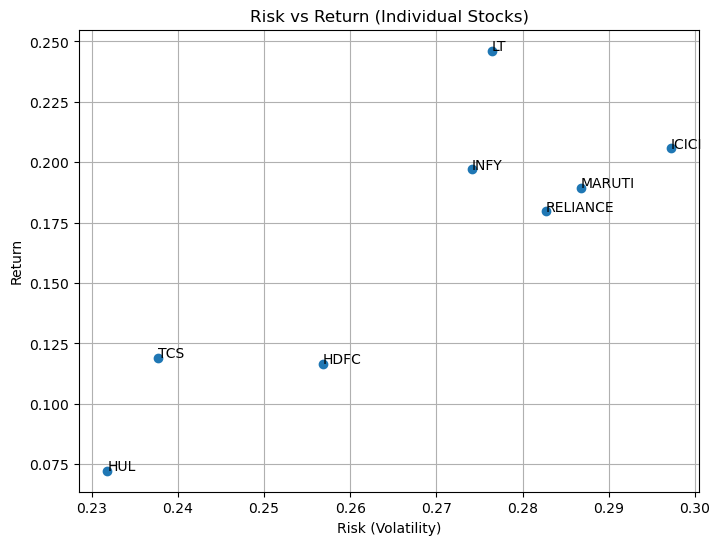

In [8]:


import matplotlib.pyplot as plt

risk_free_rate = 0.065
trading_days = 252

# Daily returns
returns = data.pct_change().dropna()

# Annualized return
annual_return = returns.mean() * trading_days

# Annualized volatility
annual_vol = returns.std() * np.sqrt(trading_days)

# Benchmark returns
benchmark_returns = returns["NIFTY50"]

# Define correct stock column names (after renaming)
stock_cols = ["HDFC", "ICICI", "TCS", "INFY", "RELIANCE", "MARUTI", "LT", "HUL"]

# Beta calculation
beta = {}
for stock in stock_cols:
    cov = np.cov(returns[stock], benchmark_returns)[0][1]
    var_benchmark = np.var(benchmark_returns)
    beta[stock] = cov / var_benchmark

beta = pd.Series(beta)

# Sharpe Ratio
sharpe = (annual_return - risk_free_rate) / annual_vol

# VaR (95%)
VaR = returns.quantile(0.05)

# Final summary table (only stocks, exclude benchmark)
summary = pd.DataFrame({
    "Annual Return": annual_return[stock_cols],
    "Annual Volatility": annual_vol[stock_cols],
    "Beta": beta,
    "Sharpe Ratio": sharpe[stock_cols],
    "VaR (95%)": VaR[stock_cols]
})

summary = summary.sort_values(by="Sharpe Ratio", ascending=False)

print(summary)

# Risk vs Return Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(summary["Annual Volatility"], summary["Annual Return"])

for stock in summary.index:
    plt.annotate(stock,
                 (summary.loc[stock, "Annual Volatility"],
                  summary.loc[stock, "Annual Return"]))

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Risk vs Return (Individual Stocks)")
plt.grid()
plt.show()

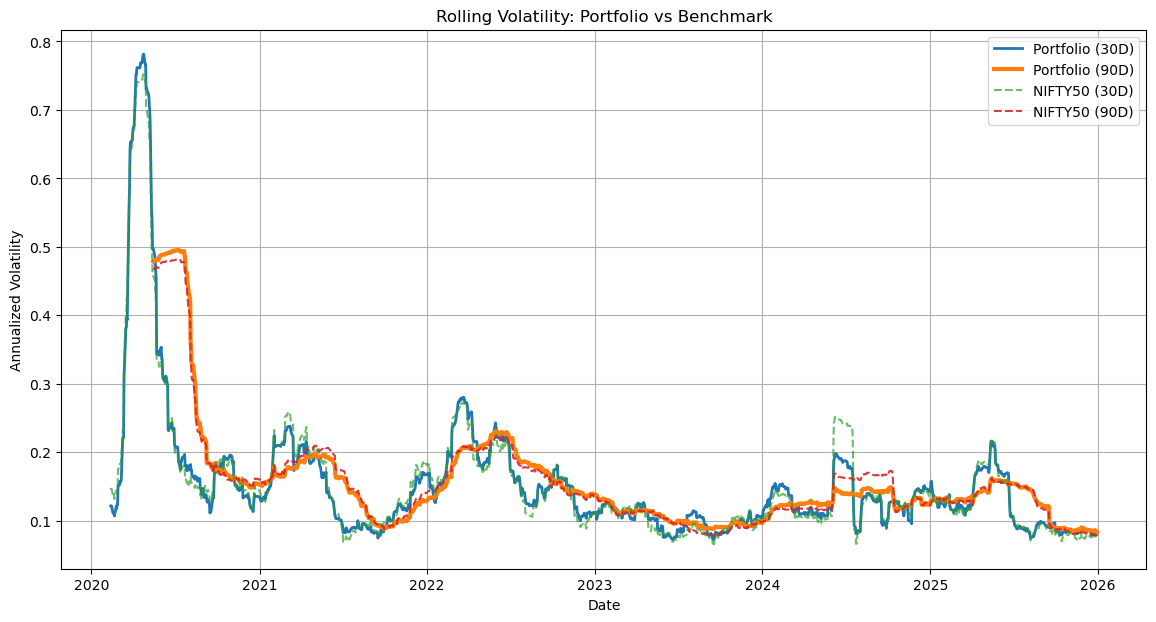

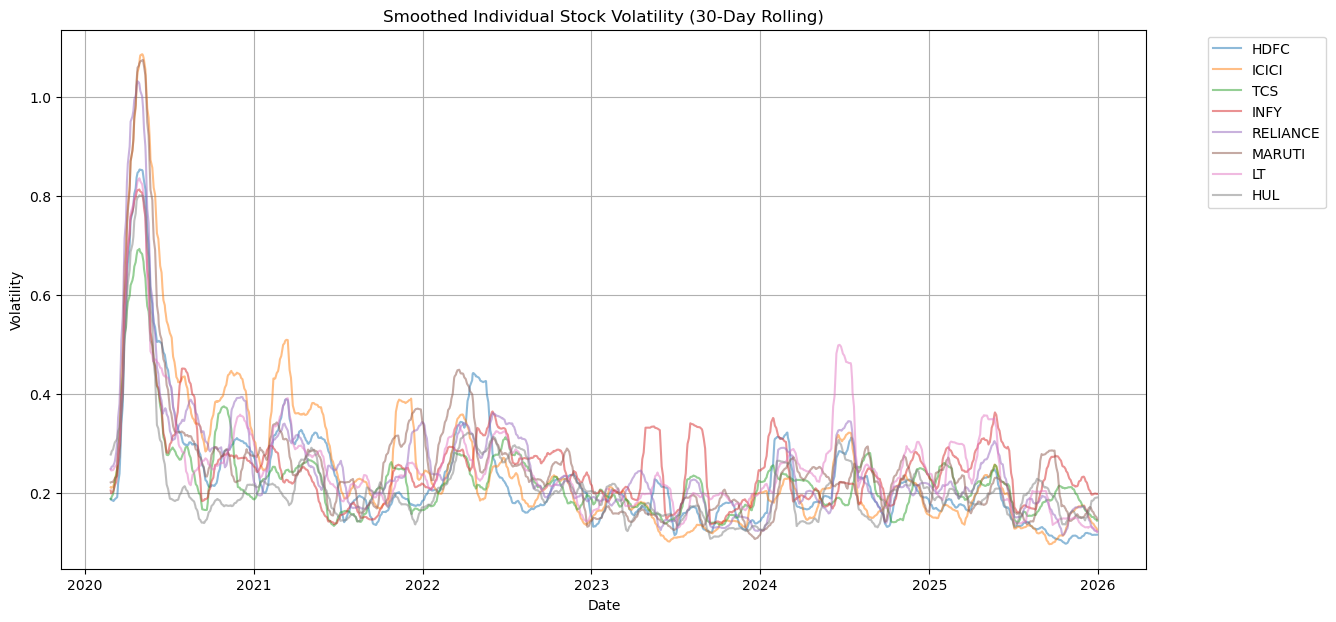

In [9]:

import matplotlib.pyplot as plt


returns = data.pct_change().dropna()

#  Portfolio Construction (Equal Weight)
stocks_only = ["HDFC", "ICICI", "TCS", "INFY", "RELIANCE", "MARUTI", "LT", "HUL"]
weights = np.array([1/len(stocks_only)] * len(stocks_only))

portfolio_returns = returns[stocks_only].dot(weights)

#  Rolling Volatility 
rolling_vol_30 = portfolio_returns.rolling(30).std() * np.sqrt(252)
rolling_vol_90 = portfolio_returns.rolling(90).std() * np.sqrt(252)

nifty_vol_30 = returns["NIFTY50"].rolling(30).std() * np.sqrt(252)
nifty_vol_90 = returns["NIFTY50"].rolling(90).std() * np.sqrt(252)

#  Plot (Clean Main Chart: Portfolio vs Benchmark) 
plt.figure(figsize=(14,7))

plt.plot(rolling_vol_30, label="Portfolio (30D)", linewidth=2)
plt.plot(rolling_vol_90, label="Portfolio (90D)", linewidth=3)

plt.plot(nifty_vol_30, linestyle='--', label="NIFTY50 (30D)", alpha=0.7)
plt.plot(nifty_vol_90, linestyle='--', label="NIFTY50 (90D)", alpha=0.9)

plt.title("Rolling Volatility: Portfolio vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid()

plt.show()

#  Smoothed Individual Volatility (Secondary Chart)
rolling_vol_individual = returns[stocks_only].rolling(30).std() * np.sqrt(252)

# Smooth noise
rolling_vol_smooth = rolling_vol_individual.rolling(10).mean()

plt.figure(figsize=(14,7))

for col in rolling_vol_smooth.columns:
    plt.plot(rolling_vol_smooth.index, rolling_vol_smooth[col], alpha=0.5)

plt.title("Smoothed Individual Stock Volatility (30-Day Rolling)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid()

plt.legend(rolling_vol_smooth.columns, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()



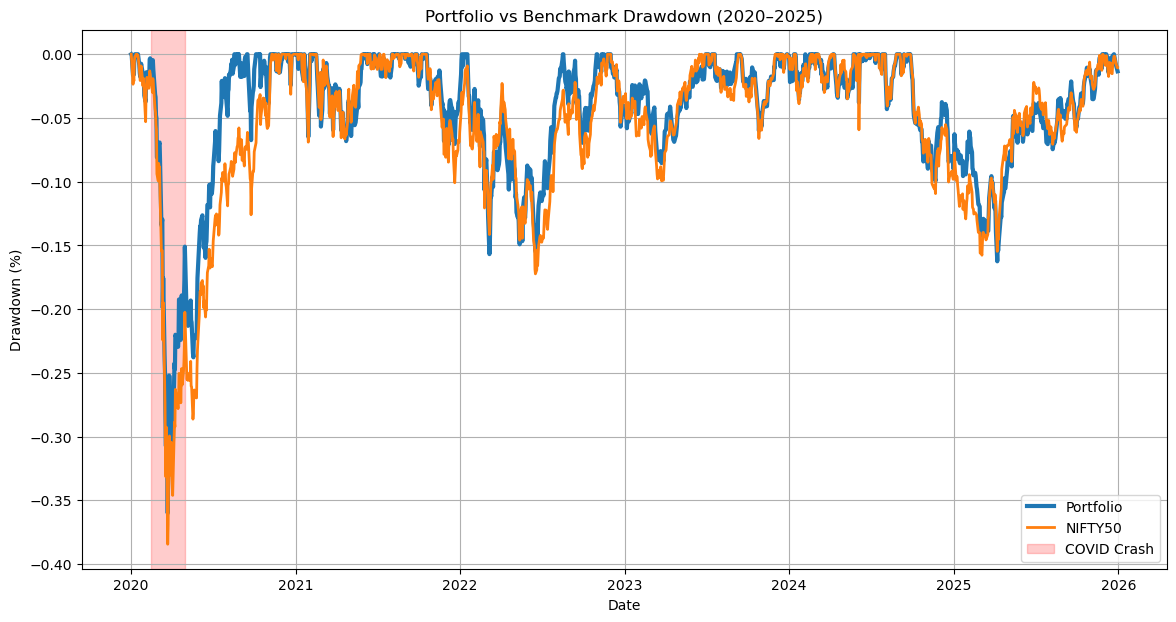

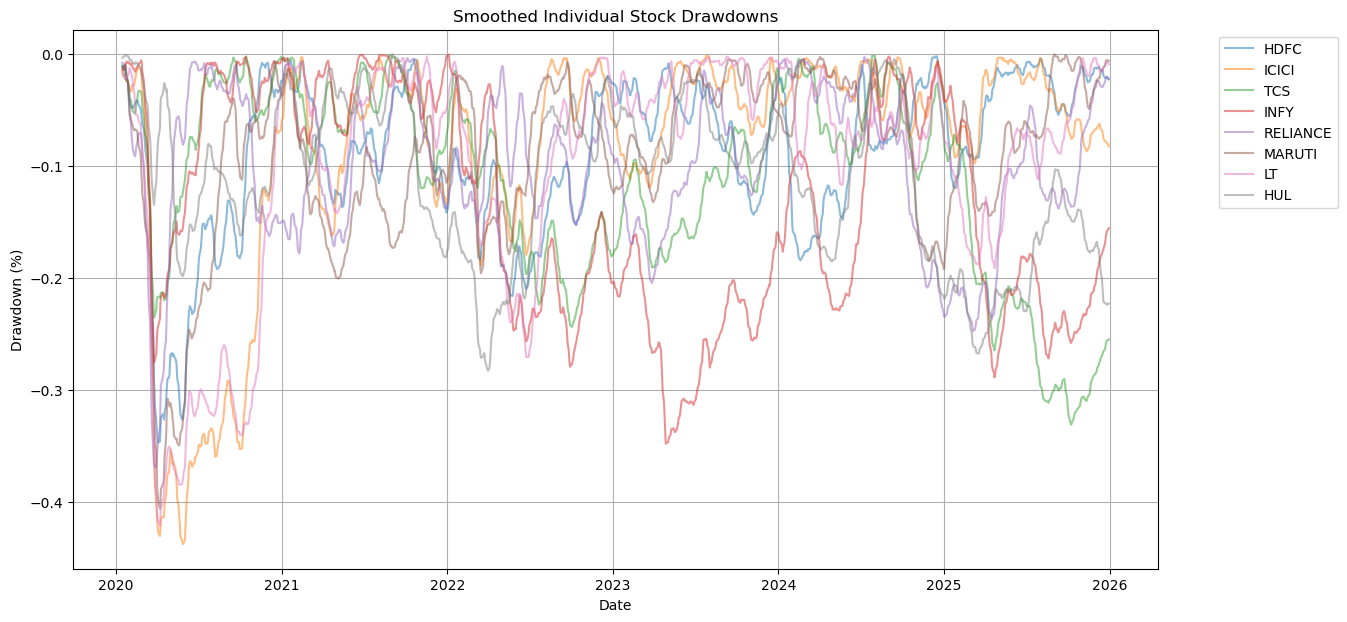


Drawdown Summary:
          Max Drawdown (%) Worst Date
Ticker                               
ICICI           -48.297832 2020-03-23
LT              -47.612459 2020-03-24
MARUTI          -46.656642 2020-04-03
RELIANCE        -44.082854 2020-03-23
HDFC            -40.465301 2020-03-24
INFY            -35.557208 2023-04-20
TCS             -34.448985 2025-09-30
HUL             -30.455789 2022-03-07


In [10]:


import matplotlib.pyplot as plt


returns = data.pct_change().dropna()

#  Portfolio Construction (Equal Weight)
stocks_only = ["HDFC", "ICICI", "TCS", "INFY", "RELIANCE", "MARUTI", "LT", "HUL"]
weights = np.array([1/len(stocks_only)] * len(stocks_only))

portfolio_returns = returns[stocks_only].dot(weights)

# Cumulative Returns 
portfolio_cum = (1 + portfolio_returns).cumprod()
nifty_cum = (1 + returns["NIFTY50"]).cumprod()

#  Drawdown Calculation 
portfolio_dd = (portfolio_cum / portfolio_cum.cummax()) - 1
nifty_dd = (nifty_cum / nifty_cum.cummax()) - 1

#  Plot (Clean Main Chart) 
plt.figure(figsize=(14,7))

plt.plot(portfolio_dd, label="Portfolio", linewidth=3)
plt.plot(nifty_dd, label="NIFTY50", linewidth=2)

# Highlight COVID crash
plt.axvspan("2020-02-15", "2020-04-30", alpha=0.2, color='red', label="COVID Crash")

plt.title("Portfolio vs Benchmark Drawdown (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid()

plt.show()

#   Individual Drawdowns (Secondary Chart)


cumulative_returns = (1 + returns[stocks_only]).cumprod()
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns / rolling_max) - 1


drawdown_smooth = drawdown.rolling(10).mean()

plt.figure(figsize=(14,7))

for col in drawdown_smooth.columns:
    plt.plot(drawdown_smooth.index, drawdown_smooth[col], alpha=0.5)

plt.title("Smoothed Individual Stock Drawdowns")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid()


plt.legend(drawdown_smooth.columns, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

#  Summary Table 
max_drawdown = drawdown.min()
worst_dates = drawdown.idxmin()

drawdown_summary = pd.DataFrame({
    "Max Drawdown (%)": max_drawdown * 100,
    "Worst Date": worst_dates
}).sort_values(by="Max Drawdown (%)")

print("\nDrawdown Summary:")
print(drawdown_summary)

In [11]:
# Exclude benchmark for stock-level analysis
stock_cols = [col for col in data.columns if col != "NIFTY50"]

# Annualized return
annual_return = returns[stock_cols].mean() * 252

# Annualized volatility
annual_vol = returns[stock_cols].std() * np.sqrt(252)

# Sharpe Ratio
risk_free_rate = 0.065
sharpe = (annual_return - risk_free_rate) / annual_vol

# Correlation with portfolio (equal-weight portfolio)
weights = np.array([1/len(stock_cols)] * len(stock_cols))
portfolio_returns = returns[stock_cols].dot(weights)

correlation_with_portfolio = returns[stock_cols].corrwith(portfolio_returns)

# Identify key metrics
best_stock = annual_return.idxmax()
least_risk = annual_vol.idxmin()
best_sharpe = sharpe.idxmax()
most_diversifying = correlation_with_portfolio.idxmin()

# Final summary table
final_summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Volatility": annual_vol,
    "Sharpe Ratio": sharpe,
    "Correlation with Portfolio": correlation_with_portfolio
}).sort_values(by="Sharpe Ratio", ascending=False)

print("\n Final Stock Summary:\n")
print(final_summary)

print("\n Key Insights:")
print("Best Performing Stock:", best_stock)
print("Least Risky Stock:", least_risk)
print("Best Risk-Adjusted Stock:", best_sharpe)
print("Most Diversifying Stock:", most_diversifying)

print("\n Optimal Portfolio Weights (Max Sharpe Portfolio):")
print(pd.Series(max_sharpe["Weights"], index=stock_cols))


 Final Stock Summary:

          Annual Return  Volatility  Sharpe Ratio  Correlation with Portfolio
Ticker                                                                       
LT             0.246176    0.276407      0.655469                    0.697739
INFY           0.197166    0.274133      0.482124                    0.680125
ICICI          0.205738    0.297220      0.473515                    0.747551
MARUTI         0.189496    0.286763      0.434142                    0.675991
RELIANCE       0.179730    0.282715      0.405815                    0.700115
TCS            0.119145    0.237664      0.227823                    0.660128
HDFC           0.116662    0.256830      0.201153                    0.715027
HUL            0.072296    0.231826      0.031471                    0.520527

 Key Insights:
Best Performing Stock: LT
Least Risky Stock: HUL
Best Risk-Adjusted Stock: LT
Most Diversifying Stock: HUL

 Optimal Portfolio Weights (Max Sharpe Portfolio):
HDFC        0.022083
